# FER2013 Data Exploration

## Facial Emotion Recognition Project

This notebook performs the first stage of the project: **exploratory data analysis and dataset validation**.

The FER2013 dataset contains grayscale facial images with a resolution of **48 × 48 pixels**. Each image belongs to one of seven emotion categories:

| Label | Emotion |
|---:|---|
| 0 | Angry |
| 1 | Disgust |
| 2 | Fear |
| 3 | Happy |
| 4 | Sad |
| 5 | Surprise |
| 6 | Neutral |

### Objectives

By the end of this notebook, we will:

1. Load and inspect the FER2013 dataset.
2. Validate its columns, labels, and pixel data.
3. Check for missing values and duplicate rows.
4. examine the official train, validation, and test splits.
5. Analyze class imbalance.
6. Visualize sample images from every emotion class.
7. Save publication-ready figures for the project report.

> This notebook does not train a neural network. Its purpose is to understand and validate the data before model development.


## 1. Import Required Libraries

The notebook uses:

- **NumPy** for numerical operations
- **Pandas** for tabular data analysis
- **Matplotlib** for visualization
- **Pathlib** for reliable file-path handling


In [12]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define Project Paths and Constants

The following code works whether the notebook is launched from the project root or from the `notebooks` directory.

Expected dataset location:

```text
data/raw/fer2013.csv
```

Generated figures will be saved in:

```text
outputs/figures/
```


In [13]:
# Detect the project root automatically
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "fer2013.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_HEIGHT = 48
IMAGE_WIDTH = 48
EXPECTED_PIXEL_COUNT = IMAGE_HEIGHT * IMAGE_WIDTH

EMOTION_LABELS = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Figures directory: {FIGURES_DIR}")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"FER2013 dataset was not found at: {DATA_PATH}\n"
        "Place fer2013.csv inside data/raw/ and run this cell again."
    )

Project root: d:\projects\facial-emotion-recognition
Dataset path: d:\projects\facial-emotion-recognition\data\raw\fer2013.csv
Figures directory: d:\projects\facial-emotion-recognition\outputs\figures


## 3. Load the FER2013 Dataset

The common FER2013 CSV format contains three columns:

- `emotion`: integer class label from 0 to 6
- `pixels`: a space-separated sequence of 2,304 grayscale pixel values
- `Usage`: official dataset split (`Training`, `PublicTest`, or `PrivateTest`)


In [14]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {df.shape[1]}")

display(df.head())

Dataset loaded successfully.
Number of rows: 35,887
Number of columns: 3


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121 119 115 110 98 91 84 84 90 99 110 126 143 153 158 171 169 172 169 165...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 154 153 164 173 178 185 185 189 187 186 193 194 185 183 186 180 173 166 ...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38 39 74 138 161 164 179 190 201 210 216 220 224 222 218 216 213 217 220...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 19 43 52 13 26 40 59 65 12 20 63 99 98 98 111 75 62 41 73 118 140 192 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84 115 127 137 142 151 156 155 149 153 152 157 160 162 159 145 121 83 58...,Training


## 4. Inspect the Dataset Structure

Before analyzing the images, we inspect:

- Column names
- Data types
- Dataset dimensions
- Basic memory usage


In [15]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame(name="dtype"))

print("\nDataset information:")
df.info()

Dataset shape: (35887, 3)

Column names:
['emotion', 'pixels', 'Usage']

Data types:


,dtype
emotion,int64
pixels,str
Usage,str



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  35887 non-null  int64
 1   pixels   35887 non-null  str  
 2   Usage    35887 non-null  str  
dtypes: int64(1), str(2)
memory usage: 841.2 KB


## 5. Validate Required Columns

This step ensures that the dataset contains the columns required by the rest of the notebook.

The `Usage` column is checked separately because some FER2013 versions may use a different split format.


In [16]:
required_columns = {"emotion", "pixels"}
missing_required_columns = required_columns.difference(df.columns)

if missing_required_columns:
    raise ValueError(
        f"The dataset is missing required columns: {sorted(missing_required_columns)}"
    )

has_usage_column = "Usage" in df.columns

print("Required columns are present.")
print(f"Official Usage column available: {has_usage_column}")

Required columns are present.
Official Usage column available: True


## 6. Add Human-Readable Emotion Names

The original dataset stores emotion labels as integers. A new column named `emotion_name` is added to make tables and plots easier to interpret.


In [17]:
df["emotion_name"] = df["emotion"].map(EMOTION_LABELS)

unknown_labels = df.loc[df["emotion_name"].isna(), "emotion"].unique()

if len(unknown_labels) > 0:
    raise ValueError(f"Unexpected emotion labels found: {unknown_labels.tolist()}")

display(df[["emotion", "emotion_name", "Usage"]].head() if has_usage_column
        else df[["emotion", "emotion_name"]].head())

,emotion,emotion_name,Usage
0,0,Angry,Training
1,0,Angry,Training
2,2,Fear,Training
3,4,Sad,Training
4,6,Neutral,Training


## 7. Dataset Quality Checks

A reliable training pipeline requires clean and consistent data. We check:

- Missing values
- Exact duplicate rows
- Valid emotion labels
- Correct number of pixels per image
- Valid grayscale intensity range


In [18]:
quality_summary = pd.DataFrame({
    "Check": [
        "Total rows",
        "Missing values",
        "Exact duplicate rows",
        "Unique emotion labels",
    ],
    "Result": [
        len(df),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        sorted(df["emotion"].unique().tolist()),
    ],
})

display(quality_summary)

print("\nMissing values by column:")
display(df.isna().sum().to_frame(name="missing_values"))

print(f"\nExact duplicate rows: {df.duplicated().sum():,}")

,Check,Result
0,Total rows,35887
1,Missing values,0
2,Exact duplicate rows,1234
3,Unique emotion labels,"[0, 1, 2, 3, 4, 5, 6]"



Missing values by column:


,missing_values
emotion,0
pixels,0
Usage,0
emotion_name,0



Exact duplicate rows: 1,234


### 7.1 Validate Pixel Sequence Length

Every FER2013 image must contain exactly:

\[
48 \times 48 = 2304
\]

pixel values.


In [19]:
pixel_lengths = df["pixels"].astype(str).str.split().str.len()
pixel_length_counts = pixel_lengths.value_counts().sort_index()

display(pixel_length_counts.to_frame(name="row_count"))

invalid_pixel_rows = pixel_lengths != EXPECTED_PIXEL_COUNT
invalid_pixel_count = int(invalid_pixel_rows.sum())

print(f"Expected pixels per image: {EXPECTED_PIXEL_COUNT}")
print(f"Rows with invalid pixel counts: {invalid_pixel_count:,}")

if invalid_pixel_count > 0:
    display(df.loc[invalid_pixel_rows, ["emotion", "pixels"]].head())

,row_count
pixels,
2304,35887


Expected pixels per image: 2304
Rows with invalid pixel counts: 0


### 7.2 Convert Pixel Strings to Images

The helper function below converts a space-separated pixel string into a NumPy array with shape `(48, 48)`.

It also validates the number of pixels before reshaping.


In [20]:
def pixels_to_image(pixel_string: str) -> np.ndarray:
    """Convert a FER2013 pixel string into a 48×48 grayscale image."""
    pixels = np.fromstring(str(pixel_string), sep=" ", dtype=np.float32)

    if pixels.size != EXPECTED_PIXEL_COUNT:
        raise ValueError(
            f"Expected {EXPECTED_PIXEL_COUNT} pixels, but received {pixels.size}."
        )

    return pixels.reshape(IMAGE_HEIGHT, IMAGE_WIDTH)


# Test the helper function on the first row
first_image = pixels_to_image(df.iloc[0]["pixels"])

print("Image shape:", first_image.shape)
print("Minimum pixel value:", first_image.min())
print("Maximum pixel value:", first_image.max())
print("Mean pixel value:", round(float(first_image.mean()), 2))

Image shape: (48, 48)
Minimum pixel value: 11.0
Maximum pixel value: 210.0
Mean pixel value: 117.59


### 7.3 Validate Pixel Intensity Range

FER2013 grayscale pixel values should normally be between **0 and 255**.


In [21]:
global_min = 255.0
global_max = 0.0

for pixel_string in df["pixels"]:
    pixels = np.fromstring(str(pixel_string), sep=" ", dtype=np.float32)

    if pixels.size == 0:
        continue

    global_min = min(global_min, float(pixels.min()))
    global_max = max(global_max, float(pixels.max()))

print(f"Global minimum pixel value: {global_min}")
print(f"Global maximum pixel value: {global_max}")

if global_min < 0 or global_max > 255:
    print("Warning: Pixel values outside the expected [0, 255] range were found.")
else:
    print("All inspected pixel values are within the expected [0, 255] range.")

Global minimum pixel value: 0.0
Global maximum pixel value: 255.0
All inspected pixel values are within the expected [0, 255] range.


## 8. Analyze the Official Dataset Splits

The standard FER2013 CSV commonly defines:

- `Training` as the training set
- `PublicTest` as the validation set
- `PrivateTest` as the final test set

Keeping the official split prevents accidental data leakage and makes results easier to compare with other FER2013 experiments.


In [22]:
if has_usage_column:
    split_counts = df["Usage"].value_counts()
    split_percentages = (split_counts / len(df) * 100).round(2)

    split_summary = pd.DataFrame({
        "Number of images": split_counts,
        "Percentage": split_percentages,
    })

    display(split_summary)
else:
    print(
        "The dataset does not contain a Usage column. "
        "A custom train/validation/test split will be required later."
    )

,Number of images,Percentage
Usage,,
Training,28709,80.0
PublicTest,3589,10.0
PrivateTest,3589,10.0


## 9. Analyze Emotion Class Distribution

Class distribution is important because an imbalanced dataset can cause the model to favor classes with more training examples.

FER2013 is known to contain fewer samples for some emotions, especially `Disgust`.


In [23]:
class_order = [EMOTION_LABELS[i] for i in sorted(EMOTION_LABELS)]
class_counts = (
    df["emotion_name"]
    .value_counts()
    .reindex(class_order)
)

class_percentages = (class_counts / len(df) * 100).round(2)

class_distribution = pd.DataFrame({
    "Number of images": class_counts,
    "Percentage": class_percentages,
})

display(class_distribution)

,Number of images,Percentage
emotion_name,,
Angry,4953,13.80
Disgust,547,1.52
Fear,5121,14.27
Happy,8989,25.05
Sad,6077,16.93
Surprise,4002,11.15
Neutral,6198,17.27


### 9.1 Plot and Save Class Distribution

The chart below is saved as:

```text
outputs/figures/class_distribution.png
```


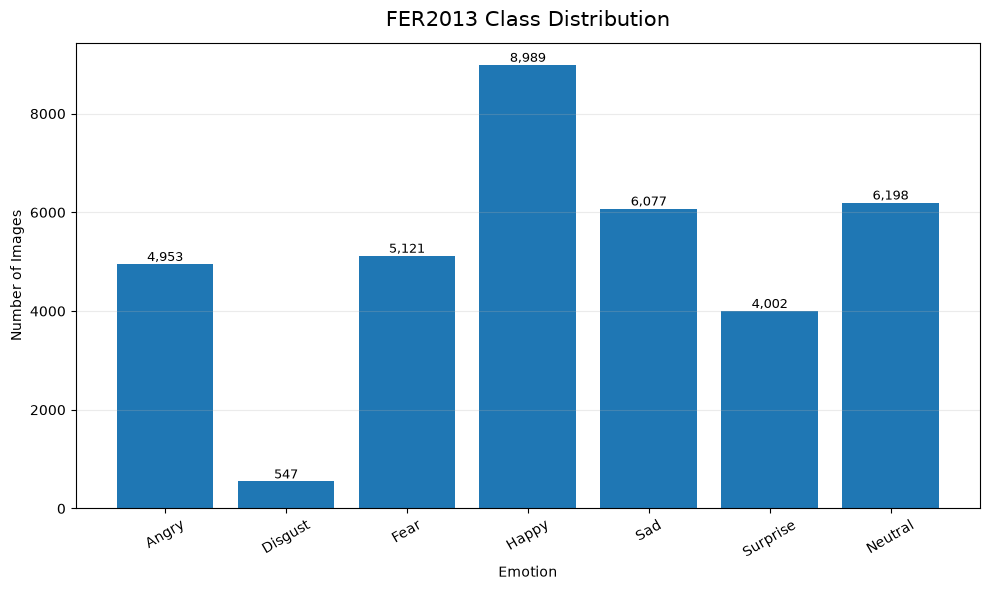

Figure saved to: d:\projects\facial-emotion-recognition\outputs\figures\class_distribution.png


In [24]:
figure_path = FIGURES_DIR / "class_distribution.png"

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(class_distribution.index, class_distribution["Number of images"])

ax.set_title("FER2013 Class Distribution", fontsize=15, pad=12)
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of Images")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, class_distribution["Number of images"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {figure_path}")

## 10. Display a Single Sample Image

This simple visualization confirms that the pixel parser reconstructs the image correctly.


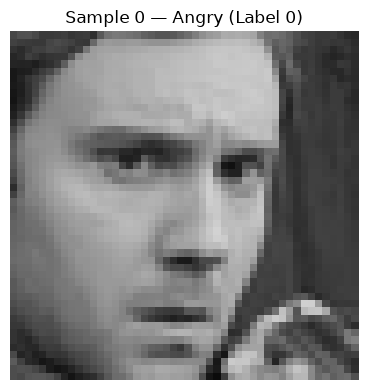

In [25]:
sample_index = 0
sample_row = df.iloc[sample_index]
sample_image = pixels_to_image(sample_row["pixels"])

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap="gray", vmin=0, vmax=255)
plt.title(
    f"Sample {sample_index} — {sample_row['emotion_name']} "
    f"(Label {sample_row['emotion']})"
)
plt.axis("off")
plt.tight_layout()
plt.show()

## 11. Visualize Samples from Every Emotion Class

The following figure displays five randomly selected images from each emotion class.

This visualization helps identify:

- Facial-expression variability
- Low-resolution or ambiguous examples
- Possible label noise
- Similarities between classes

The result is saved as:

```text
outputs/figures/emotion_samples.png
```


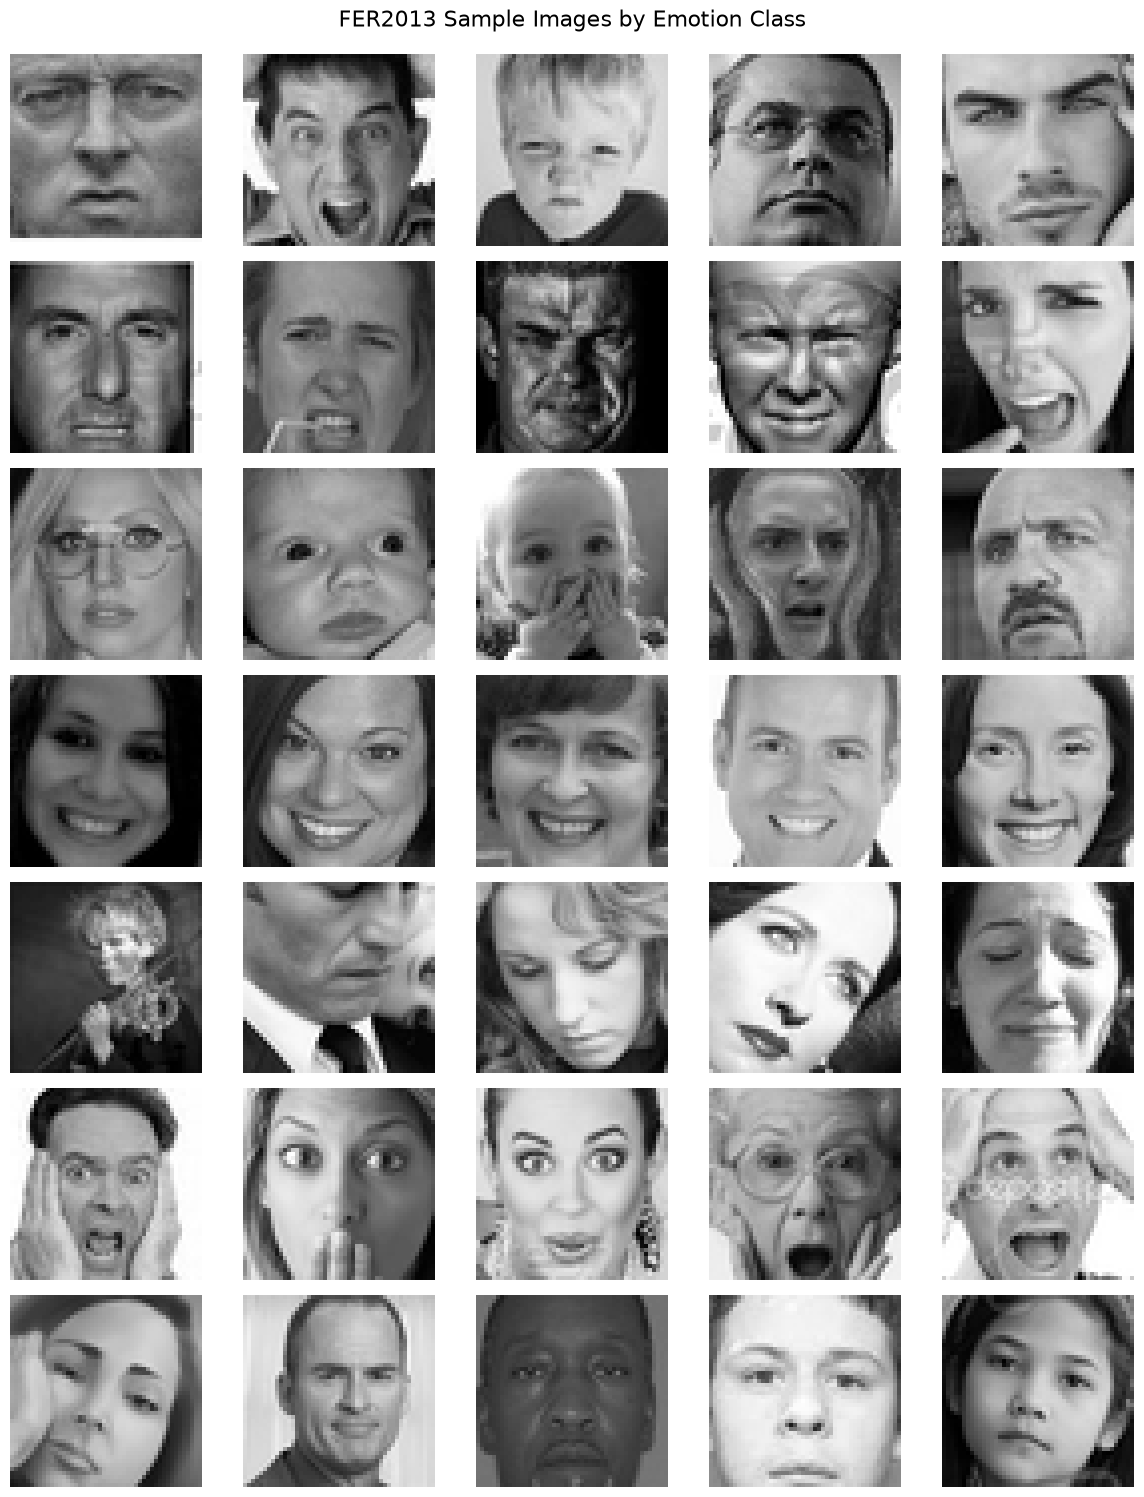

Figure saved to: d:\projects\facial-emotion-recognition\outputs\figures\emotion_samples.png


In [26]:
samples_per_class = 5
emotion_samples_path = FIGURES_DIR / "emotion_samples.png"

fig, axes = plt.subplots(
    nrows=len(EMOTION_LABELS),
    ncols=samples_per_class,
    figsize=(12, 15),
)

for emotion_id, emotion_name in EMOTION_LABELS.items():
    class_rows = df[df["emotion"] == emotion_id]

    sample_count = min(samples_per_class, len(class_rows))
    sampled_rows = class_rows.sample(
        n=sample_count,
        random_state=RANDOM_SEED,
    )

    for column_index in range(samples_per_class):
        ax = axes[emotion_id, column_index]
        ax.axis("off")

        if column_index < sample_count:
            row = sampled_rows.iloc[column_index]
            image = pixels_to_image(row["pixels"])
            ax.imshow(image, cmap="gray", vmin=0, vmax=255)

        if column_index == 0:
            ax.set_ylabel(
                emotion_name,
                rotation=0,
                labelpad=45,
                va="center",
                fontsize=11,
                fontweight="bold",
            )

fig.suptitle(
    "FER2013 Sample Images by Emotion Class",
    fontsize=16,
    y=0.995,
)
plt.tight_layout()
plt.savefig(emotion_samples_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {emotion_samples_path}")

## 12. Class Distribution by Dataset Split

A good dataset split should contain examples of every emotion in training, validation, and test sets.

This table also helps reveal whether class imbalance is consistent across the official splits.


In [27]:
if has_usage_column:
    split_class_table = pd.crosstab(
        index=df["emotion_name"],
        columns=df["Usage"],
    ).reindex(class_order)

    display(split_class_table)
else:
    print("Split-level class analysis is unavailable because Usage is missing.")

Usage,PrivateTest,PublicTest,Training
emotion_name,,,
Angry,491,467,3995
Disgust,55,56,436
Fear,528,496,4097
Happy,879,895,7215
Sad,594,653,4830
Surprise,416,415,3171
Neutral,626,607,4965


## 13. Basic Image Intensity Statistics

The following summary estimates the brightness characteristics of the images.

These statistics can help detect unusual values or preprocessing inconsistencies before model training.


In [28]:
image_means = []
image_stds = []

for pixel_string in df["pixels"]:
    image = pixels_to_image(pixel_string)
    image_means.append(float(image.mean()))
    image_stds.append(float(image.std()))

intensity_summary = pd.DataFrame({
    "Statistic": ["Mean", "Standard deviation", "Minimum", "Maximum"],
    "Image mean intensity": [
        np.mean(image_means),
        np.std(image_means),
        np.min(image_means),
        np.max(image_means),
    ],
    "Image contrast (pixel std)": [
        np.mean(image_stds),
        np.std(image_stds),
        np.min(image_stds),
        np.max(image_stds),
    ],
}).round(3)

display(intensity_summary)

,Statistic,Image mean intensity,Image contrast (pixel std)
0,Mean,129.386,54.057
1,Standard deviation,33.522,13.663
2,Minimum,0.000,0.000
3,Maximum,248.087,114.152


## 14. Final Validation Summary

This cell produces a concise checklist for confirming that the dataset is ready for the preprocessing and model-training stages.


In [29]:
validation_results = {
    "Dataset file exists": DATA_PATH.exists(),
    "Required columns exist": len(missing_required_columns) == 0,
    "All emotion labels are valid": df["emotion_name"].notna().all(),
    "All images contain 2304 pixels": invalid_pixel_count == 0,
    "No missing pixel strings": df["pixels"].notna().all(),
    "Pixel values are within [0, 255]": global_min >= 0 and global_max <= 255,
    "All seven emotion classes are present": set(df["emotion"].unique()) == set(EMOTION_LABELS),
    "Class distribution figure exists": (FIGURES_DIR / "class_distribution.png").exists(),
    "Emotion samples figure exists": (FIGURES_DIR / "emotion_samples.png").exists(),
}

validation_table = pd.DataFrame(
    {
        "Check": validation_results.keys(),
        "Passed": validation_results.values(),
    }
)

display(validation_table)

if all(validation_results.values()):
    print("Dataset validation completed successfully.")
else:
    failed_checks = [
        check for check, passed in validation_results.items() if not passed
    ]
    print("The following checks need attention:")
    for check in failed_checks:
        print(f"- {check}")

,Check,Passed
0,Dataset file exists,True
1,Required columns exist,True
2,All emotion labels are valid,True
3,All images contain 2304 pixels,True
4,No missing pixel strings,True
5,"Pixel values are within [0, 255]",True
6,All seven emotion classes are present,True
7,Class distribution figure exists,True
8,Emotion samples figure exists,True


Dataset validation completed successfully.


## 15. Findings and Next Step

After running all cells, record the following observations for the final report:

- Total number of images
- Number of images in each official split
- Most frequent and least frequent emotion classes
- Whether missing or malformed rows were found
- Whether duplicate records exist
- Whether all pixel values are valid
- Visual observations about image quality and label ambiguity

### Expected General Observation

FER2013 is a challenging dataset because:

- Images have a low resolution of 48 × 48 pixels.
- Facial expressions may be subtle or ambiguous.
- Some classes contain fewer examples than others.
- Emotions such as fear, sadness, anger, and neutral can look visually similar.
- Real-world factors such as head pose, lighting, occlusion, and facial identity increase variation.

### Next Step

The next stage is to build a reproducible preprocessing and data-loading pipeline that:

1. Converts pixel strings into arrays.
2. Normalizes pixel values.
3. Produces tensors with shape `(48, 48, 1)`.
4. Preserves the official training, validation, and test splits.
5. Supports augmentation only for the training set.
